## Carga de archivos RAW

Obtiene archivos de   
- https://huggingface.co/datasets/BioLaySumm/BioLaySumm2025-PLOS

Agrupa por texto y clasificacion

In [13]:
!pip install -r requirements.txt

#### 1. Importación de librerias

In [2]:
from datasets import load_dataset
from huggingface_hub import list_repo_files, hf_hub_download
import pandas as pd
from pathlib import Path
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

#### 2. Creación de directorios

In [ ]:
ROOT_DIR = os.path.join(os.getcwd(), '..', '..')
DATA_RAW = Path(ROOT_DIR) / "datos/raw"
DATA_PREPR = Path(ROOT_DIR) / "datos/pre-processed"
DATA_BIO = DATA_RAW / "biolaysumm-plos"
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PREPR.mkdir(parents=True, exist_ok=True)

### 3.1 Descarga de Datasets
Los datasets son descargados en su formato original

In [32]:
def download_dataset_biolay():
    name = "BioLaySumm/BioLaySumm2025-PLOS"
    DATA_BIO.mkdir(parents=True, exist_ok=True)
    files = list_repo_files(name, repo_type="dataset")
    parquet_files = [f for f in files if f.endswith(".parquet")]
    for f in parquet_files:
        lname = f.lower()
        local_file = hf_hub_download(repo_id=name, repo_type="dataset", filename=f)
        df = pd.read_parquet(local_file)
        outp = DATA_BIO / Path(lname).name
        df.to_parquet(outp, index=False)

In [33]:
download_dataset_biolay()

### 4. Conversión y unificación a CSV

In [35]:
temp_raw = pd.read_parquet(DATA_BIO)
temp_raw.head(5)

,article,summary,section_headings,keywords,year,title
0,The intensification of intervention activities...,,"[Abstract, Introduction, Materials and methods...","[infectious disease epidemiology, diagnostic m...",,
1,Tumor microenvironments ( TMEs ) contain vast ...,,"[Abstract, Introduction, Materials and methods...","[organisms, numerical analysis, simulation and...",,
2,Abnormally strong neural synchronization may i...,,"[Abstract, Introduction, Model and methods, Re...","[developmental neuroscience, biology and life ...",,
3,Some animals can regenerate large missing regi...,,"[Abstract, Introduction, Results, Discussion, ...","[organisms, morphogenesis, animals, zoology, b...",,
4,New HIV vaccine approaches are focused on elic...,,"[Abstract, Introduction, Materials and methods...","[organisms, pathogens, pathology and laborator...",,


In [41]:
df_biolay=temp_raw[['article','summary']]
df_biolay=df_biolay.replace('', np.nan)
df_biolay=df_biolay.dropna()
df_biolay.shape

(26149, 2)

Estadísticas de longitud (en palabras):
       article  summary
count  26149.0  26149.0
mean    6753.4    194.9
std     2264.3     36.8
min      748.0      4.0
25%     5166.0    174.0
50%     6581.0    202.0
75%     8091.0    218.0
max    26643.0    511.0


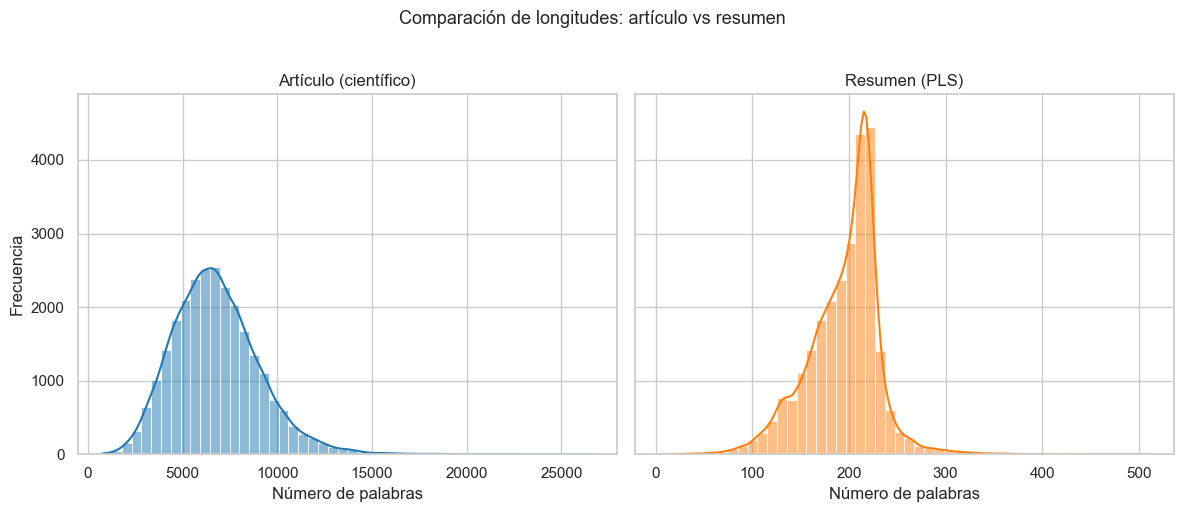

In [37]:
df = df_biolay.copy()
df["len_article_words"] = df["article"].astype(str).apply(lambda x: len(x.split()))
df["len_summary_words"] = df["summary"].astype(str).apply(lambda x: len(x.split()))

df["len_article_chars"] = df["article"].astype(str).apply(len)
df["len_summary_chars"] = df["summary"].astype(str).apply(len)

# --- Estadísticas resumen ---
print("Estadísticas de longitud (en palabras):")
print(pd.DataFrame({
    "article": df["len_article_words"].describe().round(1),
    "summary": df["len_summary_words"].describe().round(1)
}))

# --- Configurar estilo ---
sns.set(style="whitegrid", palette="Set2")

# --- Subplots lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.histplot(df["len_article_words"], bins=50, color="tab:blue", ax=axes[0], kde=True)
axes[0].set_title("Artículo (científico)")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Frecuencia")

sns.histplot(df["len_summary_words"], bins=50, color="tab:orange", ax=axes[1], kde=True)
axes[1].set_title("Resumen (PLS)")
axes[1].set_xlabel("Número de palabras")

plt.suptitle("Comparación de longitudes: artículo vs resumen", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()